In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from torchvision import transforms
from torchvision.models import resnet18

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.13.0+cpu
Device: cpu


In [2]:
import os

# Notebook is inside OncoVision AI/notebooks
PROJECT_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "..")
)

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "lung",
    "Data"
)

TRAIN_DIR = os.path.join(
    DATA_DIR,
    "train"
)

VALID_DIR = os.path.join(
    DATA_DIR,
    "valid"
)

TEST_DIR = os.path.join(
    DATA_DIR,
    "test"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "lung"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

print("Project directory:")
print(PROJECT_DIR)

print("\nData directory:")
print(DATA_DIR)

print("\nTrain directory:")
print(TRAIN_DIR)

print("\nValidation directory:")
print(VALID_DIR)

print("\nTest directory:")
print(TEST_DIR)

print("\nModel directory:")
print(MODEL_DIR)

Project directory:
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI

Data directory:
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\lung\Data

Train directory:
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\lung\Data\train

Validation directory:
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\lung\Data\valid

Test directory:
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\lung\Data\test

Model directory:
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\models\lung


In [3]:
print("Folders inside data/lung:")

lung_dir = os.path.join(
    PROJECT_DIR,
    "data",
    "lung"
)

print(
    os.listdir(lung_dir)
)

Folders inside data/lung:
['Data', 'test', 'train', 'valid']


In [4]:
import os

# Project root
PROJECT_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "..")
)

# Correct dataset location
DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "lung"
)

TRAIN_DIR = os.path.join(
    DATA_DIR,
    "train"
)

VALID_DIR = os.path.join(
    DATA_DIR,
    "valid"
)

TEST_DIR = os.path.join(
    DATA_DIR,
    "test"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "lung"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

print("Project:", PROJECT_DIR)
print("Data:", DATA_DIR)
print("Train:", TRAIN_DIR)
print("Valid:", VALID_DIR)
print("Test :", TEST_DIR)
print("Models:", MODEL_DIR)

Project: C:\Users\Vinay\OneDrive\Desktop\OncoVision AI
Data: C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\lung
Train: C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\lung\train
Valid: C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\lung\valid
Test : C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\lung\test
Models: C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\models\lung


In [5]:
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Valid exists:", os.path.exists(VALID_DIR))
print("Test exists :", os.path.exists(TEST_DIR))

print("\nTRAIN CLASSES:")
print(os.listdir(TRAIN_DIR))

print("\nVALID CLASSES:")
print(os.listdir(VALID_DIR))

print("\nTEST CLASSES:")
print(os.listdir(TEST_DIR))

Train exists: True
Valid exists: True
Test exists : True

TRAIN CLASSES:
['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']

VALID CLASSES:
['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']

TEST CLASSES:
['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']


In [6]:
import os
import pandas as pd

CLASS_NAMES = [
    "normal",
    "adenocarcinoma",
    "large.cell.carcinoma",
    "squamous.cell.carcinoma"
]

CLASS_TO_IDX = {
    "normal": 0,
    "adenocarcinoma": 1,
    "large.cell.carcinoma": 2,
    "squamous.cell.carcinoma": 3
}

IDX_TO_CLASS = {
    0: "normal",
    1: "adenocarcinoma",
    2: "large.cell.carcinoma",
    3: "squamous.cell.carcinoma"
}


def normalize_class(folder_name):

    name = folder_name.lower()

    if name == "normal":
        return "normal"

    if "adenocarcinoma" in name:
        return "adenocarcinoma"

    if "large.cell.carcinoma" in name:
        return "large.cell.carcinoma"

    if "squamous.cell.carcinoma" in name:
        return "squamous.cell.carcinoma"

    return None


def create_dataframe(directory):

    records = []

    for root, dirs, files in os.walk(directory):

        folder = os.path.basename(root)

        label_name = normalize_class(folder)

        if label_name is None:
            continue

        for file in files:

            if file.lower().endswith(
                (".png", ".jpg", ".jpeg")
            ):

                records.append({
                    "filepath": os.path.join(
                        root,
                        file
                    ),
                    "label": label_name,
                    "target": CLASS_TO_IDX[label_name]
                })

    return pd.DataFrame(records)


train_df = create_dataframe(TRAIN_DIR)
valid_df = create_dataframe(VALID_DIR)
test_df = create_dataframe(TEST_DIR)


print("Training samples  :", len(train_df))
print("Validation samples:", len(valid_df))
print("Test samples      :", len(test_df))

print("\nTRAIN DISTRIBUTION")
print(
    train_df["label"].value_counts()
)

print("\nVALIDATION DISTRIBUTION")
print(
    valid_df["label"].value_counts()
)

print("\nTEST DISTRIBUTION")
print(
    test_df["label"].value_counts()
)

Training samples  : 613
Validation samples: 72
Test samples      : 315

TRAIN DISTRIBUTION
label
adenocarcinoma             195
squamous.cell.carcinoma    155
normal                     148
large.cell.carcinoma       115
Name: count, dtype: int64

VALIDATION DISTRIBUTION
label
adenocarcinoma             23
large.cell.carcinoma       21
squamous.cell.carcinoma    15
normal                     13
Name: count, dtype: int64

TEST DISTRIBUTION
label
adenocarcinoma             120
squamous.cell.carcinoma     90
normal                      54
large.cell.carcinoma        51
Name: count, dtype: int64


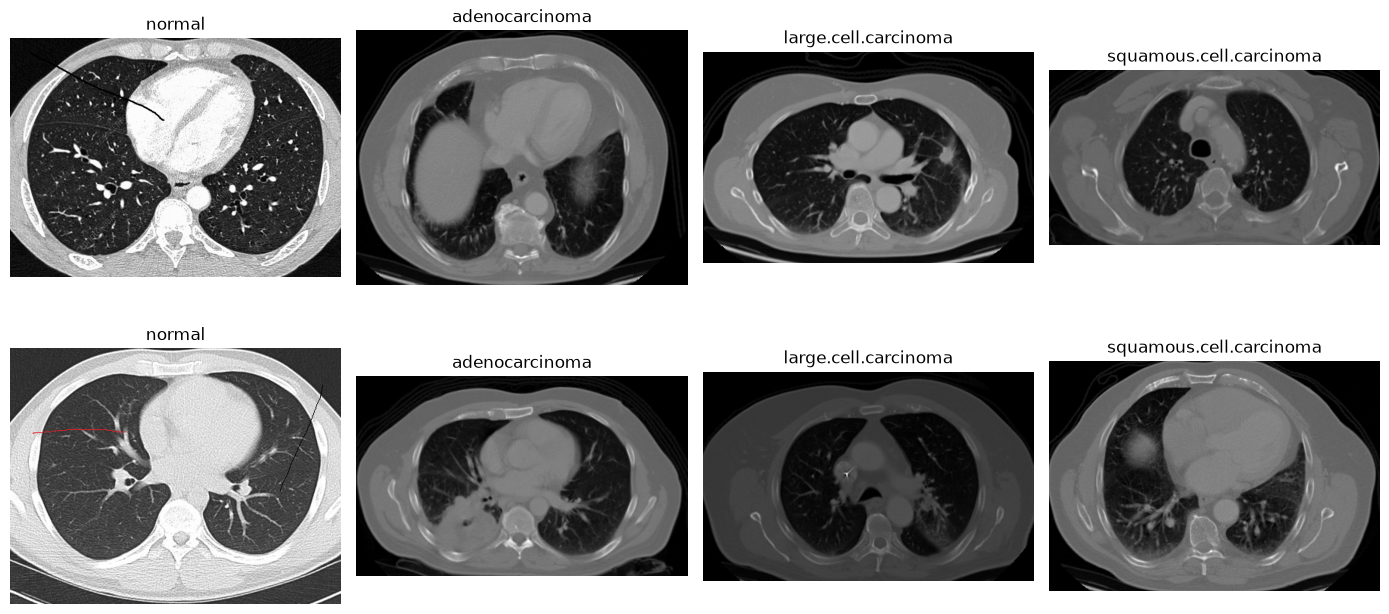

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 7)
)

for col, class_name in enumerate(CLASS_NAMES):

    samples = train_df[
        train_df["label"] == class_name
    ].sample(
        2,
        random_state=42
    )

    for row, (_, item) in enumerate(
        samples.iterrows()
    ):

        image = Image.open(
            item["filepath"]
        ).convert("RGB")

        axes[row, col].imshow(image)

        axes[row, col].set_title(
            class_name
        )

        axes[row, col].axis("off")


plt.tight_layout()
plt.show()

In [8]:
print("Image size examples:")

for path in train_df["filepath"].head(10):

    img = Image.open(path)

    print(
        img.size
    )

Image size examples:
(409, 264)
(397, 243)
(392, 244)
(377, 220)
(373, 272)
(449, 288)
(389, 276)
(384, 328)
(417, 323)
(341, 247)


## preprocessing


In [9]:
import torch
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Data augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    # ImageNet normalization for pretrained ResNet18
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training preprocessing ready!")
print("Image size:", IMG_SIZE)

Training preprocessing ready!
Image size: 224


In [10]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image


class LungDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        label = int(
            row["target"]
        )

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = LungDataset(
    train_df,
    train_transform
)

valid_dataset = LungDataset(
    valid_df,
    valid_test_transform
)

test_dataset = LungDataset(
    test_df,
    valid_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(valid_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 613
Validation dataset: 72
Test dataset: 315


In [11]:
image, label = train_dataset[0]

print("Tensor shape:", image.shape)
print("Label:", label)
print("Class:", IDX_TO_CLASS[label])

Tensor shape: torch.Size([3, 224, 224])
Label: 1
Class: adenocarcinoma


In [12]:
from torch.utils.data import WeightedRandomSampler, DataLoader
import torch
import numpy as np

# Count samples in each class
class_counts = (
    train_df["target"]
    .value_counts()
    .sort_index()
)

print("Class counts:")
print(class_counts)

# Weight for each class
class_weights = (
    len(train_df)
    / (len(CLASS_NAMES) * class_counts)
)

print("\nClass weights:")
print(class_weights)

# Weight for every training sample
sample_weights = train_df["target"].map(
    class_weights
).values

sample_weights = torch.tensor(
    sample_weights,
    dtype=torch.double
)

# Balanced sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("\nBalanced DataLoader created!")
print("Training batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Class counts:
target
0    148
1    195
2    115
3    155
Name: count, dtype: int64

Class weights:
target
0    1.035473
1    0.785897
2    1.332609
3    0.988710
Name: count, dtype: float64

Balanced DataLoader created!
Training batches: 20
Validation batches: 3
Test batches: 10


In [13]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

print("\nLabels in batch:")
print(labels)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])

Labels in batch:
tensor([3, 0, 2, 2, 2, 2, 1, 2, 1, 0, 1, 0, 3, 2, 3, 3, 3, 0, 0, 1, 2, 3, 1, 2,
        2, 1, 1, 3, 0, 3, 0, 0])


In [14]:
import torch.nn as nn
from torchvision.models import resnet18

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# Pretrained ResNet18
model = resnet18(weights="DEFAULT")

# Replace original ImageNet classifier
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(
        model.fc.in_features,
        4
    )
)

model = model.to(device)

print("\nFinal classifier:")
print(model.fc)

Using device: cpu

Final classifier:
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=4, bias=True)
)


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [16]:
# ============================================================
# LUNG CANCER RESNET18 - INITIAL TRAINING
# ============================================================

EPOCHS = 12

best_val_loss = float("inf")

patience = 4
patience_counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_resnet18_lung_stage1.pth"
)


for epoch in range(EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    train_loss = (
        running_loss / total
    )

    train_acc = (
        correct / total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    val_loss = (
        val_running_loss / val_total
    )

    val_acc = (
        val_correct / val_total
    )


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_acc
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step(
        val_loss
    )


    # ========================================================
    # BEST MODEL
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            "  → Best Stage-1 model saved!"
        )

    else:

        patience_counter += 1

        print(
            f"  → No improvement "
            f"({patience_counter}/{patience})"
        )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= patience:

        print(
            "\nEarly stopping triggered."
        )

        break


print("\nStage-1 training completed!")

print(
    "Best model:",
    BEST_MODEL_PATH
)

Epoch [1/12] Train Loss: 1.3466 Train Acc: 0.3736 Val Loss: 1.2743 Val Acc: 0.4722
  → Best Stage-1 model saved!
Epoch [2/12] Train Loss: 1.1081 Train Acc: 0.5122 Val Loss: 1.0974 Val Acc: 0.4861
  → Best Stage-1 model saved!
Epoch [3/12] Train Loss: 1.0460 Train Acc: 0.5253 Val Loss: 0.9900 Val Acc: 0.5833
  → Best Stage-1 model saved!
Epoch [4/12] Train Loss: 0.9616 Train Acc: 0.5677 Val Loss: 0.9754 Val Acc: 0.5556
  → Best Stage-1 model saved!
Epoch [5/12] Train Loss: 0.9192 Train Acc: 0.6183 Val Loss: 0.9832 Val Acc: 0.5556
  → No improvement (1/4)
Epoch [6/12] Train Loss: 0.8894 Train Acc: 0.6297 Val Loss: 0.9148 Val Acc: 0.6528
  → Best Stage-1 model saved!
Epoch [7/12] Train Loss: 0.8321 Train Acc: 0.6574 Val Loss: 0.8842 Val Acc: 0.6389
  → Best Stage-1 model saved!
Epoch [8/12] Train Loss: 0.8734 Train Acc: 0.6052 Val Loss: 0.8744 Val Acc: 0.5972
  → Best Stage-1 model saved!
Epoch [9/12] Train Loss: 0.7851 Train Acc: 0.6737 Val Loss: 0.8749 Val Acc: 0.6944
  → No improvement

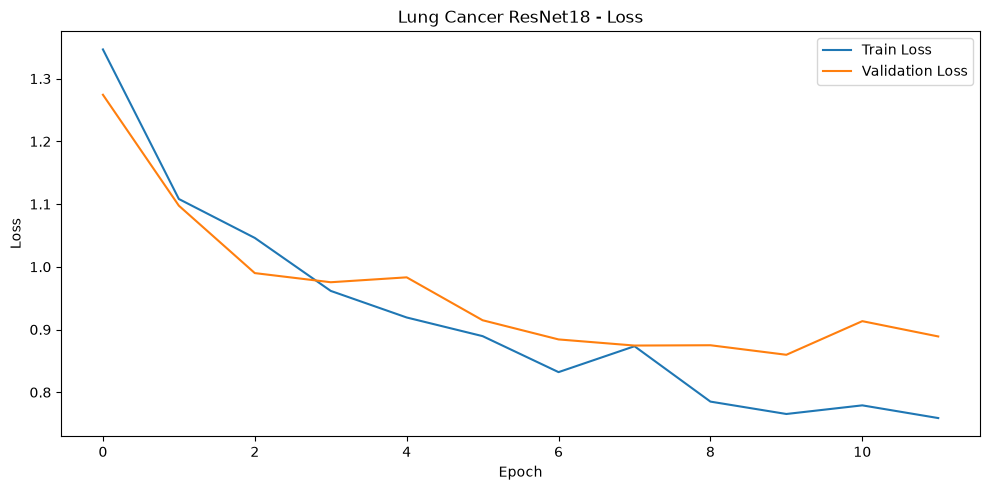

In [17]:
# ============================================================
# TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Lung Cancer ResNet18 - Loss"
)

plt.legend()

plt.tight_layout()

plt.show()

In [18]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [19]:
# ============================================================
# LUNG CANCER RESNET18 - STAGE 2 FINE-TUNING
# ============================================================

# Load best Stage-1 model
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Keep earlier layers frozen
for param in model.layer1.parameters():
    param.requires_grad = False

for param in model.layer2.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = False

# Classifier remains trainable
for param in model.fc.parameters():
    param.requires_grad = True


# Count parameters
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)


# ============================================================
# FINE-TUNING OPTIMIZER
# ============================================================

fine_tune_optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.0001,
    weight_decay=1e-4
)

fine_tune_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    fine_tune_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


# ============================================================
# TRAINING SETTINGS
# ============================================================

FINE_TUNE_EPOCHS = 10

best_fine_val_loss = float("inf")

fine_patience = 4
fine_patience_counter = 0

fine_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


FINE_TUNED_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_resnet18_lung_finetuned.pth"
)


# ============================================================
# FINE-TUNING LOOP
# ============================================================

for epoch in range(FINE_TUNE_EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        fine_tune_optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        fine_tune_optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    train_loss = running_loss / total
    train_acc = correct / total


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    fine_history[
        "train_loss"
    ].append(train_loss)

    fine_history[
        "train_acc"
    ].append(train_acc)

    fine_history[
        "val_loss"
    ].append(val_loss)

    fine_history[
        "val_acc"
    ].append(val_acc)


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(
        f"Fine-tune Epoch [{epoch+1}/{FINE_TUNE_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )


    # --------------------------------------------------------
    # LEARNING RATE SCHEDULER
    # --------------------------------------------------------

    fine_tune_scheduler.step(
        val_loss
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_loss < best_fine_val_loss:

        best_fine_val_loss = val_loss

        fine_patience_counter = 0

        torch.save(
            model.state_dict(),
            FINE_TUNED_MODEL_PATH
        )

        print(
            "  → Best fine-tuned lung model saved!"
        )

    else:

        fine_patience_counter += 1

        print(
            f"  → No improvement "
            f"({fine_patience_counter}/{fine_patience})"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if fine_patience_counter >= fine_patience:

        print(
            "\nFine-tuning early stopping triggered."
        )

        break


print(
    "\nStage-2 fine-tuning completed!"
)

print(
    "Best model:",
    FINE_TUNED_MODEL_PATH
)

Trainable parameters: 8405316
Total parameters: 11178564
Fine-tune Epoch [1/10] Train Loss: 0.5749 Train Acc: 0.7814 Val Loss: 0.7170 Val Acc: 0.7083
  → Best fine-tuned lung model saved!
Fine-tune Epoch [2/10] Train Loss: 0.3982 Train Acc: 0.8467 Val Loss: 0.6138 Val Acc: 0.7917
  → Best fine-tuned lung model saved!
Fine-tune Epoch [3/10] Train Loss: 0.2745 Train Acc: 0.9103 Val Loss: 0.4777 Val Acc: 0.8194
  → Best fine-tuned lung model saved!
Fine-tune Epoch [4/10] Train Loss: 0.1727 Train Acc: 0.9478 Val Loss: 0.4259 Val Acc: 0.8472
  → Best fine-tuned lung model saved!
Fine-tune Epoch [5/10] Train Loss: 0.1191 Train Acc: 0.9674 Val Loss: 0.3841 Val Acc: 0.8750
  → Best fine-tuned lung model saved!
Fine-tune Epoch [6/10] Train Loss: 0.0914 Train Acc: 0.9690 Val Loss: 0.3359 Val Acc: 0.9028
  → Best fine-tuned lung model saved!
Fine-tune Epoch [7/10] Train Loss: 0.0657 Train Acc: 0.9853 Val Loss: 0.3873 Val Acc: 0.8750
  → No improvement (1/4)
Fine-tune Epoch [8/10] Train Loss: 0.08

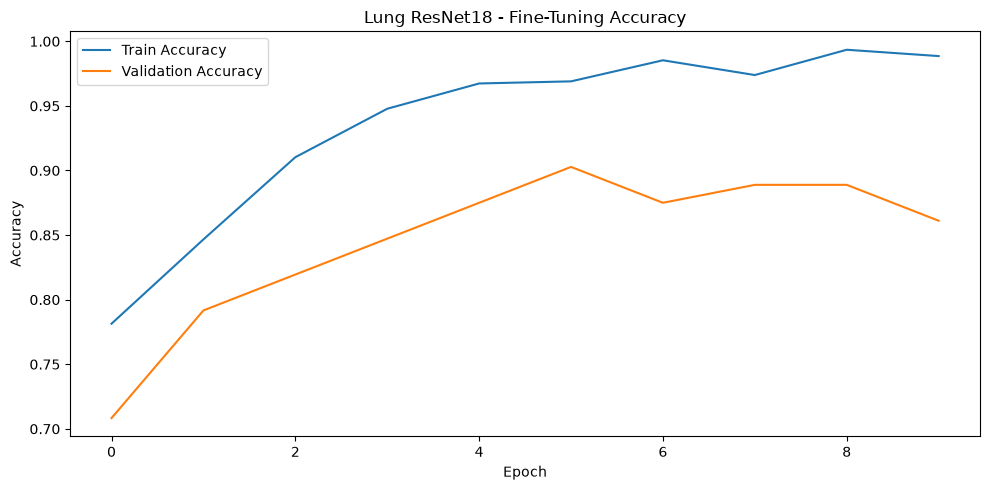

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    fine_history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    fine_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Lung ResNet18 - Fine-Tuning Accuracy"
)

plt.legend()

plt.tight_layout()

plt.show()

In [21]:
# ============================================================
# LUNG CANCER RESNET18 - FINAL TEST EVALUATION
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)


# ============================================================
# LOAD BEST MODEL
# ============================================================

model.load_state_dict(
    torch.load(
        FINE_TUNED_MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best fine-tuned model loaded!")
print(FINE_TUNED_MODEL_PATH)


# ============================================================
# TEST PREDICTIONS
# ============================================================

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )


all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities,
    multi_class="ovr",
    average="macro"
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n")
print("=" * 45)
print("       LUNG RESNET18 TEST EVALUATION")
print("=" * 45)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)

print(
    f"ROC-AUC  : {roc_auc:.4f}"
)

print("=" * 45)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

Best fine-tuned model loaded!
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\models\lung\best_resnet18_lung_finetuned.pth


       LUNG RESNET18 TEST EVALUATION
Accuracy : 0.8159
Precision: 0.8547
Recall   : 0.8432
F1 Score : 0.8270
ROC-AUC  : 0.9717

Classification Report:

                         precision    recall  f1-score   support

                 normal     1.0000    0.9815    0.9907        54
         adenocarcinoma     0.7448    0.9000    0.8151       120
   large.cell.carcinoma     0.7353    0.9804    0.8403        51
squamous.cell.carcinoma     0.9388    0.5111    0.6619        90

               accuracy                         0.8159       315
              macro avg     0.8547    0.8432    0.8270       315
           weighted avg     0.8424    0.8159    0.8055       315



<Figure size 900x700 with 0 Axes>

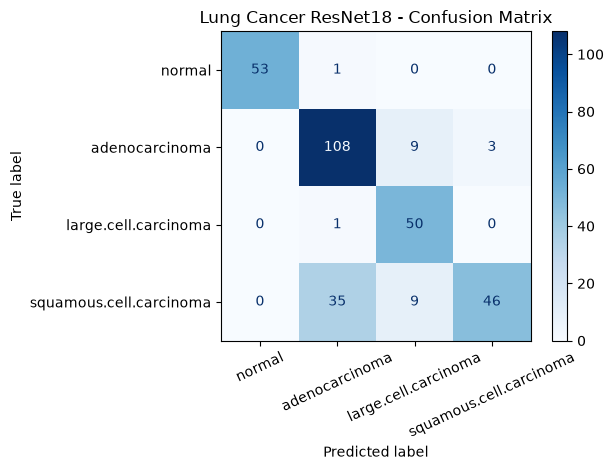

In [22]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(
    figsize=(9, 7)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Lung Cancer ResNet18 - Confusion Matrix"
)

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

In [23]:
print("\nActual test distribution:")

for i, name in enumerate(CLASS_NAMES):

    print(
        f"{name}:",
        np.sum(all_labels == i)
    )


print("\nPredicted test distribution:")

for i, name in enumerate(CLASS_NAMES):

    print(
        f"{name}:",
        np.sum(all_predictions == i)
    )


Actual test distribution:
normal: 54
adenocarcinoma: 120
large.cell.carcinoma: 51
squamous.cell.carcinoma: 90

Predicted test distribution:
normal: 53
adenocarcinoma: 145
large.cell.carcinoma: 68
squamous.cell.carcinoma: 49


In [24]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

                         precision    recall  f1-score   support

                 normal     1.0000    0.9815    0.9907        54
         adenocarcinoma     0.7448    0.9000    0.8151       120
   large.cell.carcinoma     0.7353    0.9804    0.8403        51
squamous.cell.carcinoma     0.9388    0.5111    0.6619        90

               accuracy                         0.8159       315
              macro avg     0.8547    0.8432    0.8270       315
           weighted avg     0.8424    0.8159    0.8055       315



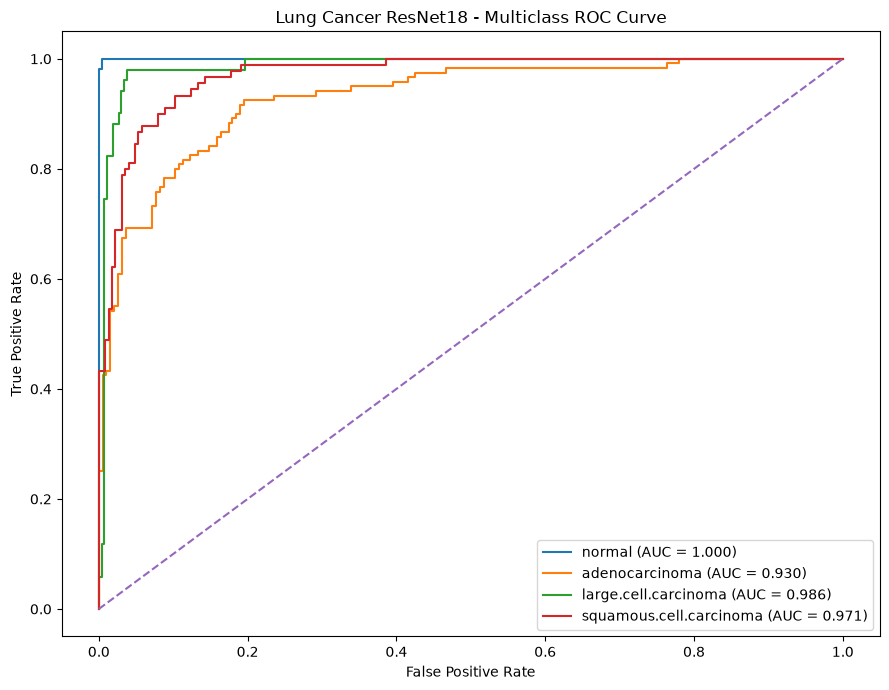

In [25]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to one-hot format
y_test_bin = label_binarize(
    all_labels,
    classes=[0, 1, 2, 3]
)

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        all_probabilities[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Lung Cancer ResNet18 - Multiclass ROC Curve"
)

plt.legend()

plt.tight_layout()

plt.show()

In [27]:
# ============================================================
# LUNG RESNET18 - LOAD BEST MODEL FOR GRAD-CAM
# ============================================================

model.load_state_dict(
    torch.load(
        FINE_TUNED_MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best lung model loaded for Grad-CAM.")
print(FINE_TUNED_MODEL_PATH)


Best lung model loaded for Grad-CAM.
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\models\lung\best_resnet18_lung_finetuned.pth


In [28]:
# ResNet18 Grad-CAM target layer

target_layer = model.layer4[-1].conv2

print("Grad-CAM target layer:")
print(target_layer)

Grad-CAM target layer:
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


In [29]:
# ============================================================
# LUNG RESNET18 - GRAD-CAM
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms


# ------------------------------------------------------------
# GRAD-CAM CLASS
# ------------------------------------------------------------

class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Forward hook
        self.forward_hook = target_layer.register_forward_hook(
            self.save_activation
        )

        # Backward hook
        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradient
        )


    def save_activation(
        self,
        module,
        input,
        output
    ):

        self.activations = output.detach()


    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0].detach()


    def generate(
        self,
        image_tensor,
        target_class
    ):

        self.model.zero_grad()

        output = self.model(
            image_tensor
        )

        score = output[
            0,
            target_class
        ]

        score.backward()

        # Get activations and gradients
        activations = self.activations[0]

        gradients = self.gradients[0]

        # Global average pooling of gradients
        weights = gradients.mean(
            dim=(1, 2)
        )

        # Weighted combination
        cam = torch.zeros(
            activations.shape[1:],
            device=activations.device
        )

        for i, weight in enumerate(weights):

            cam += (
                weight *
                activations[i]
            )

        # ReLU
        cam = torch.relu(cam)

        # Normalize
        cam -= cam.min()

        if cam.max() != 0:

            cam /= cam.max()

        return cam.cpu().numpy()


    def close(self):

        self.forward_hook.remove()

        self.backward_hook.remove()

In [30]:
# ============================================================
# CREATE GRAD-CAM
# ============================================================

grad_cam = GradCAM(
    model,
    target_layer
)

print("Grad-CAM initialized successfully!")

Grad-CAM initialized successfully!


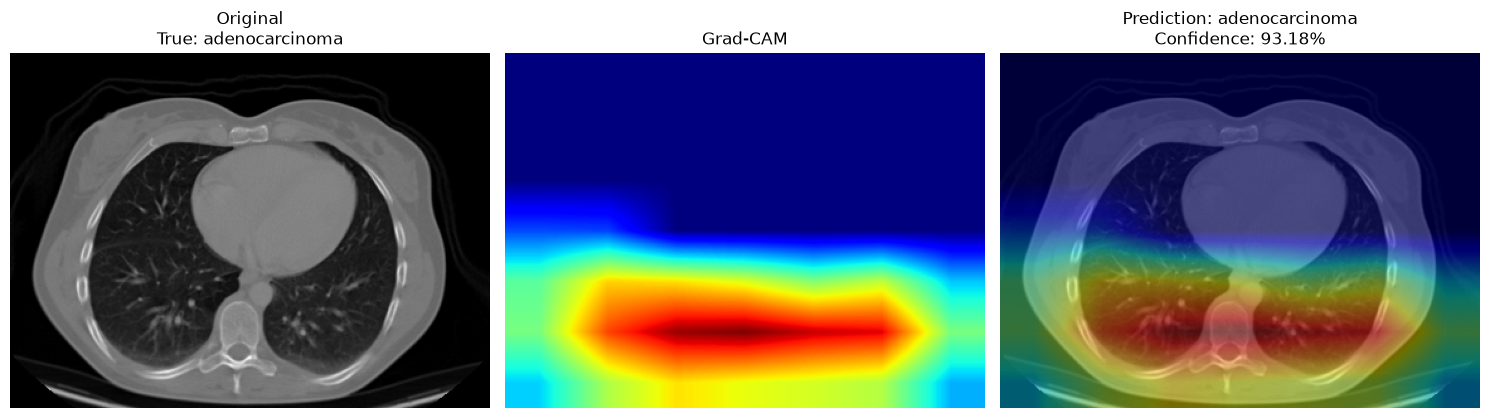

True class: adenocarcinoma
Predicted class: adenocarcinoma
Confidence: 93.18%


In [31]:
# ============================================================
# SELECT TEST IMAGE
# ============================================================

sample_index = 0

sample_row = test_df.iloc[
    sample_index
]

image_path = sample_row[
    "filepath"
]

true_label = sample_row[
    "target"
]

original_image = Image.open(
    image_path
).convert("RGB")


# ------------------------------------------------------------
# PREPROCESS
# ------------------------------------------------------------

input_tensor = valid_test_transform(
    original_image
).unsqueeze(0).to(device)


# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    output = model(
        input_tensor
    )

    probabilities = torch.softmax(
        output,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()


confidence = probabilities[
    0,
    predicted_class
].item()


# ------------------------------------------------------------
# GRAD-CAM
# ------------------------------------------------------------

cam = grad_cam.generate(
    input_tensor,
    predicted_class
)


# ------------------------------------------------------------
# RESIZE CAM
# ------------------------------------------------------------

import cv2

cam_resized = cv2.resize(
    cam,
    (
        original_image.width,
        original_image.height
    )
)


# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

plt.figure(
    figsize=(15, 5)
)


# Original
plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    original_image
)

plt.title(
    f"Original\n"
    f"True: {IDX_TO_CLASS[true_label]}"
)

plt.axis("off")


# Heatmap
plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    cam_resized,
    cmap="jet"
)

plt.title(
    "Grad-CAM"
)

plt.axis("off")


# Overlay
plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    original_image
)

plt.imshow(
    cam_resized,
    cmap="jet",
    alpha=0.45
)

plt.title(
    f"Prediction: "
    f"{IDX_TO_CLASS[predicted_class]}\n"
    f"Confidence: {confidence:.2%}"
)

plt.axis("off")


plt.tight_layout()

plt.show()


print(
    "True class:",
    IDX_TO_CLASS[true_label]
)

print(
    "Predicted class:",
    IDX_TO_CLASS[predicted_class]
)

print(
    "Confidence:",
    f"{confidence:.2%}"
)